In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv")
train_df.head(5)
print(train_df['target'].value_counts())

target
no     33384
yes     5827
Name: count, dtype: int64


**Undersamplign the Data**


In [3]:
# from sklearn.utils import resample

# # Separate majority and minority classes
# df_majority = train_df[train_df['target'] == 'no']
# df_minority = train_df[train_df['target'] == 'yes']

# # Downsample majority class
# df_majority_downsampled = resample(df_majority,
#                                    replace=False,  # Without replacement
#                                    n_samples=len(df_minority),  # Match minority class size
#                                    random_state=42)  # For reproducibility

# # Combine the downsampled majority class with the minority class
# train_df_balanced = pd.concat([df_majority_downsampled, df_minority])

# # Shuffle the dataframe (optional but recommended)
# train_df = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# # Check the class distribution
# print(train_df['target'].value_counts())







from sklearn.utils import resample

# Separate majority and minority classes
df_majority = train_df[train_df['target'] == 'no']
df_minority = train_df[train_df['target'] == 'yes']

# Exclude rows with missing values in both 'poutcome' and 'contact' columns from the majority class
df_majority_filtered = df_majority[~(df_majority['poutcome'].isna() & df_majority['contact'].isna())]

# Downsample the filtered majority class
df_majority_downsampled = resample(df_majority_filtered,
                                   replace=False,  # Without replacement
                                   n_samples=len(df_minority),  # Match minority class size
                                   random_state=42)  # For reproducibility

# Combine the downsampled majority class with the minority class
train_df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataframe (optional but recommended)
train_df = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the class distribution
print(train_df['target'].value_counts())





# from sklearn.utils import resample

# Separate majority and minority classes
# df_majority = train_df[train_df['target'] == 'no']
# df_minority = train_df[train_df['target'] == 'yes']

# # Oversample the minority class
# df_minority_oversampled = resample(df_minority,
#                                    replace=True,  # Sample with replacement
#                                    n_samples=len(df_majority),  # Match the majority class size
#                                    random_state=42)  # For reproducibility

# # Combine the oversampled minority class with the majority class
# train_df_balanced = pd.concat([df_majority, df_minority_oversampled])

# # Shuffle the dataframe (optional but recommended)
# train_df = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# # Check the class distribution
# print(train_df['target'].value_counts())


target
yes    5827
no     5827
Name: count, dtype: int64


****Dummy Model****

In [4]:
# df = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv")
# X = df.drop("target", axis=1) #it represents the feature matrix
# y = df['target'] #it contains all the labels or it is the target vector 

# from sklearn.dummy import DummyClassifier
# model = DummyClassifier().fit(X,y)

# X_test =pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv") #the data loaded only contains the target variable
# y_pred=model.predict(X_test)

# submission = pd.DataFrame({"id": range(0,X_test.shape[0]),
# "target": y_pred})

# submission.to_csv('submission.csv',index=False) #submissioon dataframe is saved to a csv file name submission.csv
# #index = false insures that the row indices are not included in the CSV file

# **EDA**

****Column types in the train data****

* **Categorical Columns** - job, marital, education, default, housing, loan, contact, poutcome, target
* **Numerical Columns** - age, balance, duration,campaign, pdays, previous
* **mixed columns** - last contact date

**UNIVARIATE ANALYSIS ON NUMERICAL COLUMNS**

1) on Age column
**conclusions:**
* majority ages are closely clustered around the mean(40 years).
* we have no person who is smaller than 18 and greater than 95
* this column is positively skewed


In [5]:
train_df['age'].describe()

count    11654.000000
mean        43.757422
std         15.421210
min         18.000000
25%         32.000000
50%         40.000000
75%         52.000000
max         95.000000
Name: age, dtype: float64

<Axes: ylabel='Density'>

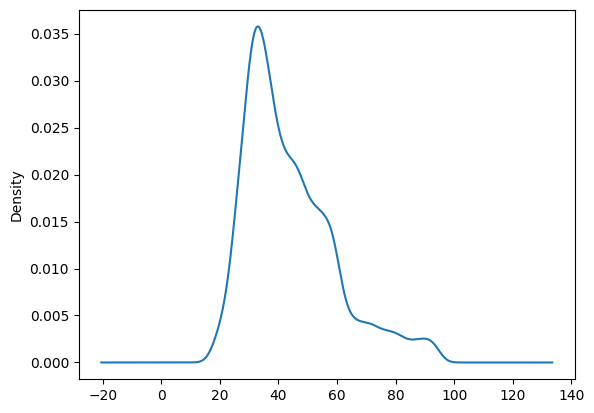

In [6]:
train_df['age'].plot(kind = 'kde')

<Axes: ylabel='Frequency'>

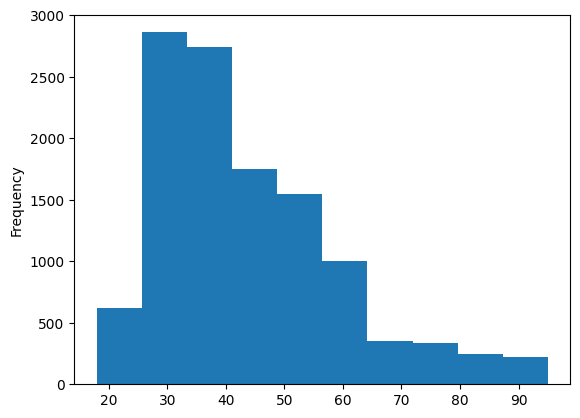

In [7]:
train_df['age'].plot(kind = 'hist',bins = 10)

In [8]:
train_df['age'].skew()
#the more than value of skew gets closer to zero the more it is normally distributed
#if it is highly negative then it is negatively skewed(right leaning)
#if it is highly positive then it is positively skewed(left leaning)

1.0548701200953021

<Axes: >

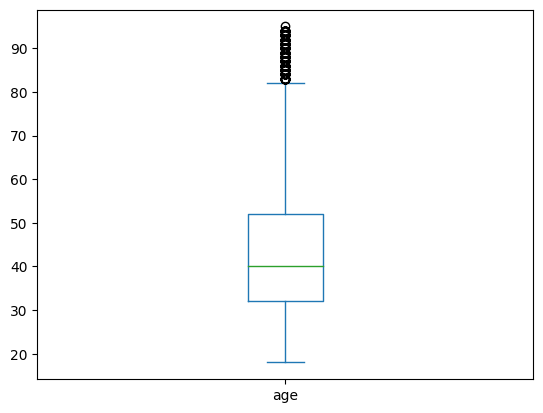

In [9]:
train_df['age'].plot(kind = 'box')

In [10]:
train_df[train_df['age']>75]

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2010-10-28,89,self-employed,divorced,tertiary,yes,96072,no,no,telephone,680,14,652,238,failure,yes
47,2008-09-04,79,student,divorced,primary,yes,28538,yes,no,telephone,3910,45,866,154,failure,yes
74,2010-03-23,90,student,divorced,primary,yes,39558,yes,no,telephone,2359,56,459,142,other,yes
80,2009-10-04,84,student,married,primary,no,75714,no,yes,cellular,4029,41,159,217,failure,yes
133,2008-03-24,80,housemaid,married,secondary,yes,10471,no,no,cellular,3894,53,714,106,other,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11568,2008-12-11,76,self-employed,married,tertiary,yes,76578,no,yes,cellular,2903,30,204,22,other,yes
11576,2009-09-27,91,self-employed,married,primary,no,18227,no,no,cellular,1375,57,283,261,failure,yes
11600,2009-09-11,87,student,single,secondary,yes,62850,yes,yes,telephone,4264,13,60,140,other,yes
11633,2009-10-22,86,student,divorced,secondary,yes,2140,yes,yes,cellular,3094,38,208,252,other,no


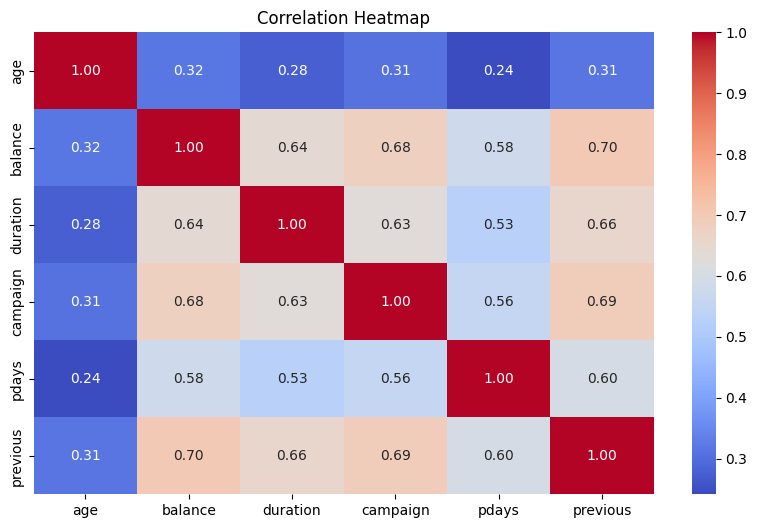

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation
numerical_df = train_df.select_dtypes(include=['float64', 'int64'])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


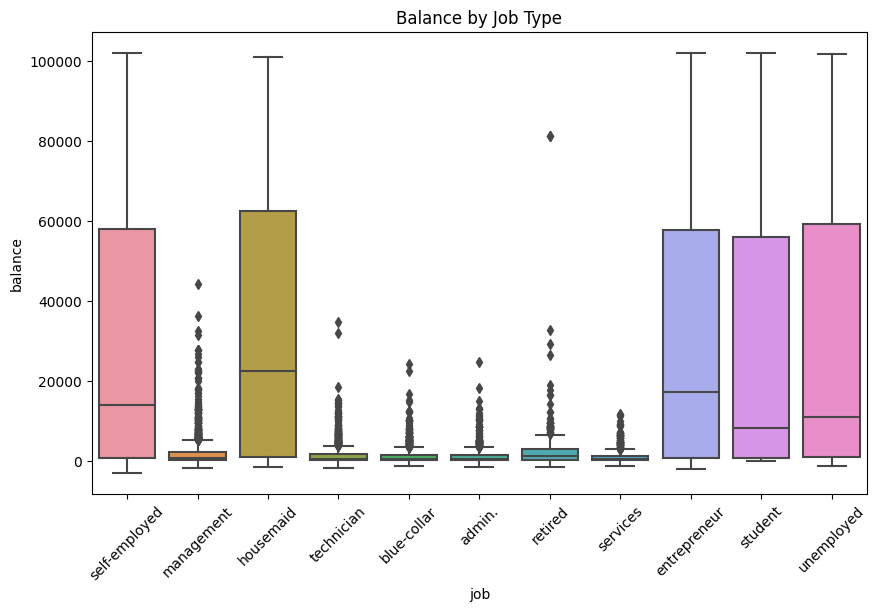

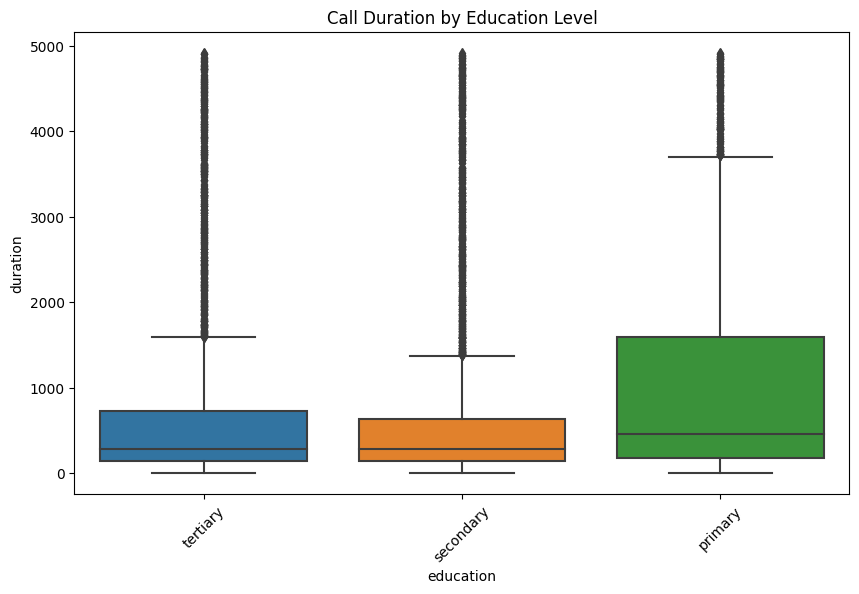

In [12]:
# Boxplot for 'job' vs 'balance'
plt.figure(figsize=(10, 6))
sns.boxplot(x='job', y='balance', data=train_df)
plt.title('Balance by Job Type')
plt.xticks(rotation=45)
plt.show()

# Boxplot for 'education' vs 'duration'
plt.figure(figsize=(10, 6))
sns.boxplot(x='education', y='duration', data=train_df)
plt.title('Call Duration by Education Level')
plt.xticks(rotation=45)
plt.show()


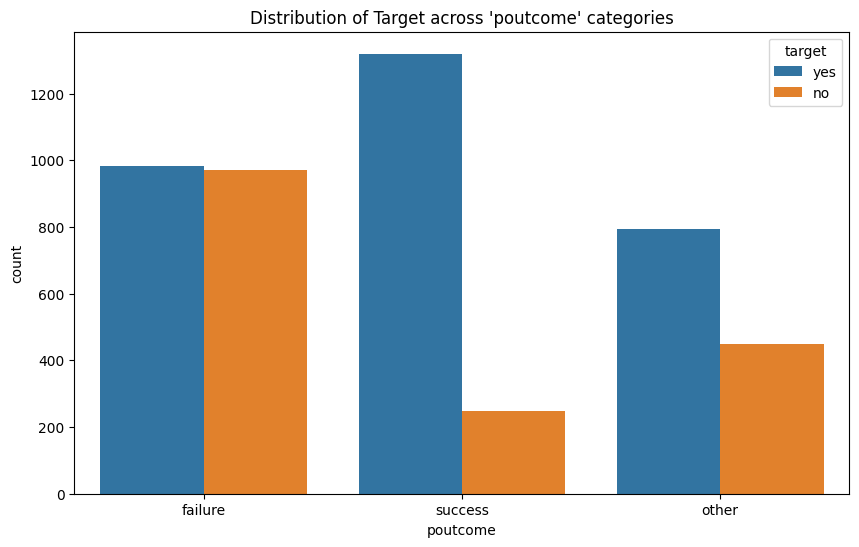

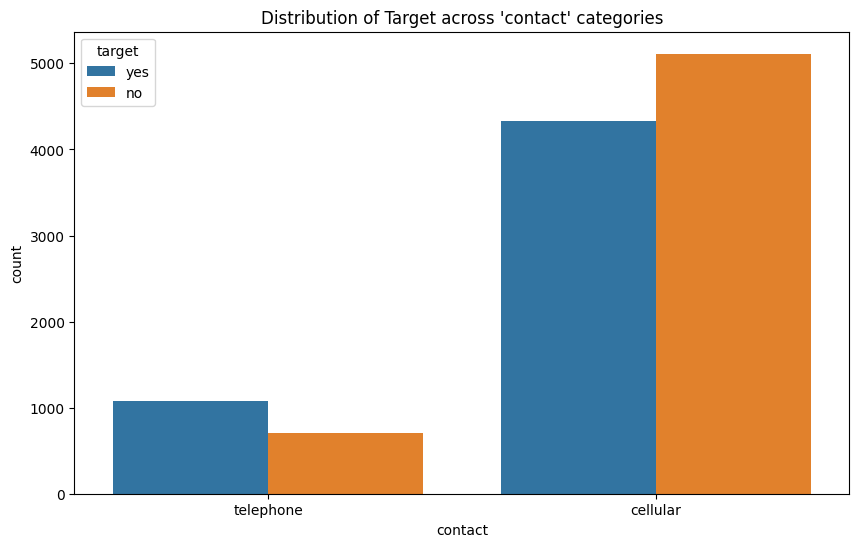

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot for 'poutcome'
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='poutcome', hue='target')
plt.title("Distribution of Target across 'poutcome' categories")
plt.show()

# Bar plot for 'contact'
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='contact', hue='target')
plt.title("Distribution of Target across 'contact' categories")
plt.show()


In [14]:
unique_values = train_df['contact'].unique()
unique_values

array(['telephone', 'cellular', nan], dtype=object)

In [15]:
missing_data_summary = train_df.isnull().sum()
missing_data_summary

last contact date       0
age                     0
job                    55
marital                 0
education             391
default                 0
balance                 0
housing                 0
loan                    0
contact               428
duration                0
campaign                0
pdays                   0
previous                0
poutcome             6886
target                  0
dtype: int64

In [16]:
# train_df.drop('job', axis=1, inplace=True)

# **Handling Missing data**

**Filling Missing values in 'job' and 'education' columns**

In [17]:
# Fill missing values in 'job' column with the mode
train_df['job'].fillna(train_df['job'].mode()[0], inplace=True)

# Fill missing values in 'education' column with the mode
train_df['education'].fillna(train_df['education'].mode()[0], inplace=True)

# Optionally, print to check if there are any remaining missing values
print(train_df.isnull().sum())


last contact date       0
age                     0
job                     0
marital                 0
education               0
default                 0
balance                 0
housing                 0
loan                    0
contact               428
duration                0
campaign                0
pdays                   0
previous                0
poutcome             6886
target                  0
dtype: int64


/tmp/ipykernel_17/3770733932.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['job'].fillna(train_df['job'].mode()[0], inplace=True)
/tmp/ipykernel_17/3770733932.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

# Filling Missing value in 'Contact' using Predective imputation technique**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Assuming you have a DataFrame 'train_df' where 'contact' column has missing values
# Extract rows where 'contact' is not missing for training the model
train_df_known = train_df[train_df['contact'].notna()]
train_df_missing = train_df[train_df['contact'].isna()]

# Encoding 'contact' column in train_df_known since it's the target variable
label_encoder = LabelEncoder()
train_df_known['contact_encoded'] = label_encoder.fit_transform(train_df_known['contact'])

# Selecting features (age, job, marital, education, default, balance, housing, loan)
features = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
X = pd.get_dummies(train_df_known[features], drop_first=True)  # One-hot encoding for categorical variables
y = train_df_known['contact_encoded']

# Splitting data for training and validation
X_train_cc, X_val_cc, y_train_cc, y_val_cc = train_test_split(X, y, test_size=0.2, random_state=42)

# Building a simple classifier model
rf_model_cc = RandomForestClassifier(random_state=42)
rf_model_cc.fit(X_train_cc, y_train_cc)

# Checking model accuracy (optional, for evaluation purposes)
accuracy = rf_model_cc.score(X_val_cc, y_val_cc)
print(f"Model Accuracy on Validation Data: {accuracy:.2f}")

# Preparing the missing data for prediction
X_missing = pd.get_dummies(train_df_missing[features], drop_first=True)

# Align the columns of X_missing with X_train (this ensures no issues due to missing columns)
X_missing = X_missing.reindex(columns=X_train_cc.columns, fill_value=0)

# Predicting missing values
predicted_contact_encoded = rf_model_cc.predict(X_missing)

# Converting the predicted labels back to original 'contact' categories
predicted_contact = label_encoder.inverse_transform(predicted_contact_encoded)

# Imputing the missing values in the original DataFrame
train_df.loc[train_df['contact'].isna(), 'contact'] = predicted_contact

# Displaying the result
print("Missing values in 'contact' have been imputed using prediction.")

/tmp/ipykernel_17/950731340.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_known['contact_encoded'] = label_encoder.fit_transform(train_df_known['contact'])


Model Accuracy on Validation Data: 0.83
Missing values in 'contact' have been imputed using prediction.


In [19]:
train_df

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2010-10-28,89,self-employed,divorced,tertiary,yes,96072,no,no,telephone,680,14,652,238,failure,yes
1,2009-08-07,56,management,married,tertiary,no,79,no,no,cellular,82,2,-1,0,NaN,no
2,2008-10-18,41,housemaid,single,secondary,yes,74359,no,no,telephone,2383,10,437,154,failure,yes
3,2010-10-15,30,management,single,tertiary,no,536,no,no,cellular,244,1,105,1,success,yes
4,2008-04-12,35,technician,married,secondary,no,2201,no,no,telephone,350,1,-1,0,NaN,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11649,2010-05-27,37,admin.,married,secondary,no,274,yes,no,cellular,731,3,-1,0,NaN,yes
11650,2008-08-06,46,technician,married,secondary,no,363,yes,no,cellular,209,3,-1,0,NaN,no
11651,2010-07-28,25,blue-collar,single,secondary,no,76,no,yes,cellular,50,4,-1,0,NaN,no
11652,2010-07-31,45,management,married,secondary,no,4105,yes,no,cellular,49,2,-1,0,NaN,no


# Filling Missing value in 'poutcome' using Predective imputation technique

In [20]:
# train_df['poutcome'].fillna(train_df['poutcome'].mode()[0], inplace=True)

from sklearn.linear_model import LogisticRegression
# Assuming you have a DataFrame 'train_df' where 'poutcome' column has missing values
# Extract rows where 'poutcome' is not missing for training the model
train_df_known_poutcome = train_df[train_df['poutcome'].notna()]
train_df_missing_poutcome = train_df[train_df['poutcome'].isna()]

# Encoding 'poutcome' column in train_df_known_poutcome since it's the target variable
label_encoder_poutcome = LabelEncoder()
train_df_known_poutcome['poutcome_encoded'] = label_encoder_poutcome.fit_transform(train_df_known_poutcome['poutcome'])

# Selecting features for prediction (you can customize this list as needed)
features_poutcome = ['age','marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact','duration','pdays','previous']  # Adding 'contact' as a feature since it may influence 'poutcome'
X_poutcome = pd.get_dummies(train_df_known_poutcome[features_poutcome], drop_first=True)  # One-hot encoding for categorical variables
y_poutcome = train_df_known_poutcome['poutcome_encoded']

# Splitting data for training and validation
X_train_poutcome, X_val_poutcome, y_train_poutcome, y_val_poutcome = train_test_split(X_poutcome, y_poutcome, test_size=0.2, random_state=42)

# Building a simple classifier model for predicting 'poutcome'
rf_model_poutcome = rf_model = RandomForestClassifier(random_state = 42)
rf_model_poutcome.fit(X_train_poutcome, y_train_poutcome)

# Checking model accuracy (optional, for evaluation purposes)
accuracy_poutcome = rf_model_poutcome.score(X_val_poutcome, y_val_poutcome)

print(f"Model Accuracy on Validation Data for 'poutcome': {accuracy_poutcome:.2f}")

# Preparing the missing data for prediction
X_missing_poutcome = pd.get_dummies(train_df_missing_poutcome[features_poutcome], drop_first=True)

# Align the columns of X_missing_poutcome with X_train_poutcome (ensuring consistent feature alignment)
X_missing_poutcome = X_missing_poutcome.reindex(columns=X_train_poutcome.columns, fill_value=0)

# Predicting missing values for 'poutcome'
# predicted_poutcome_encoded = rf_model_poutcome.predict(X_missing_poutcome)

predicted_poutcome_encoded = rf_model_poutcome.predict(X_missing_poutcome)
# Converting the predicted labels back to original 'poutcome' categories
predicted_poutcome = label_encoder_poutcome.inverse_transform(predicted_poutcome_encoded)

# Imputing the missing values in the original DataFrame
train_df.loc[train_df['poutcome'].isna(), 'poutcome'] = predicted_poutcome

# Displaying the result
print("Missing values in 'poutcome' have been imputed using prediction.")


/tmp/ipykernel_17/3138564769.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_known_poutcome['poutcome_encoded'] = label_encoder_poutcome.fit_transform(train_df_known_poutcome['poutcome'])


Model Accuracy on Validation Data for 'poutcome': 0.51
Missing values in 'poutcome' have been imputed using prediction.


In [21]:
# importances = lgr_model.feature_importances_

# # Create a DataFrame to store the feature names and their importance
# feature_importance = pd.DataFrame({
#     'Feature': X_train_poutcome.columns,
#     'Importance': importances
# })

# # Sort the features by importance
# feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# # Plot the feature importance
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Importance'])
# plt.title('Feature Importance using Random Forest')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()

# # Display the feature importance
# print(feature_importance)

In [22]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # List of columns to check against 'poutcome'
# columns = ['age', 'job', 'marital', 'education', 'default', 'balance', 
#            'housing', 'loan', 'contact', 'duration', 'pdays', 'previous']

# # Set the style for the plots
# sns.set(style="whitegrid")

# # Create a figure with subplots
# fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
# axes = axes.flatten()

# # Loop over each column and create a plot for each
# for i, col in enumerate(columns):
#     if test_df[col].dtype == 'object':  # Categorical columns
#         sns.countplot(data=test_df, x=col, hue='poutcome', ax=axes[i])
#         axes[i].set_title(f'Relationship of {col} with poutcome')
#     else:  # Continuous columns
#         sns.boxplot(data=test_df, x='poutcome', y=col, ax=axes[i])
#         axes[i].set_title(f'Relationship of {col} with poutcome')

# # Adjust layout
# plt.tight_layout()
# plt.show()


# Comparing how the distribution of potcome and contact was earlier vs. now

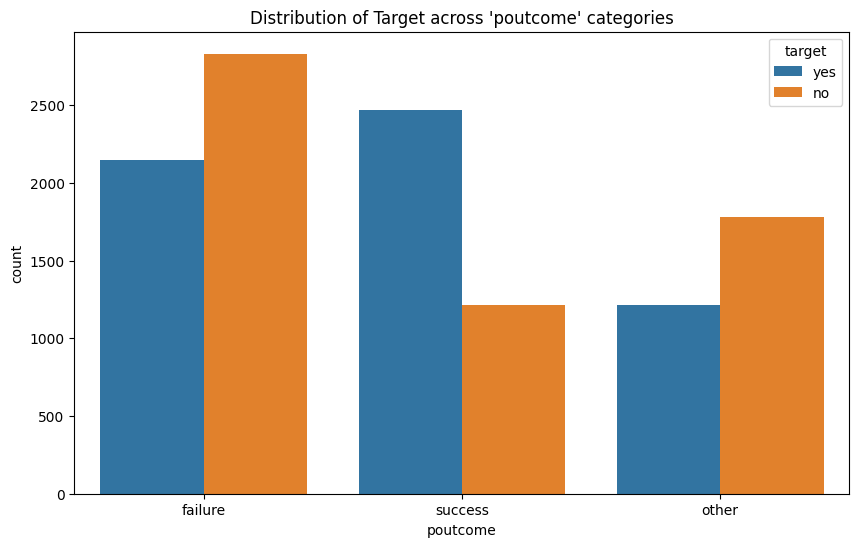

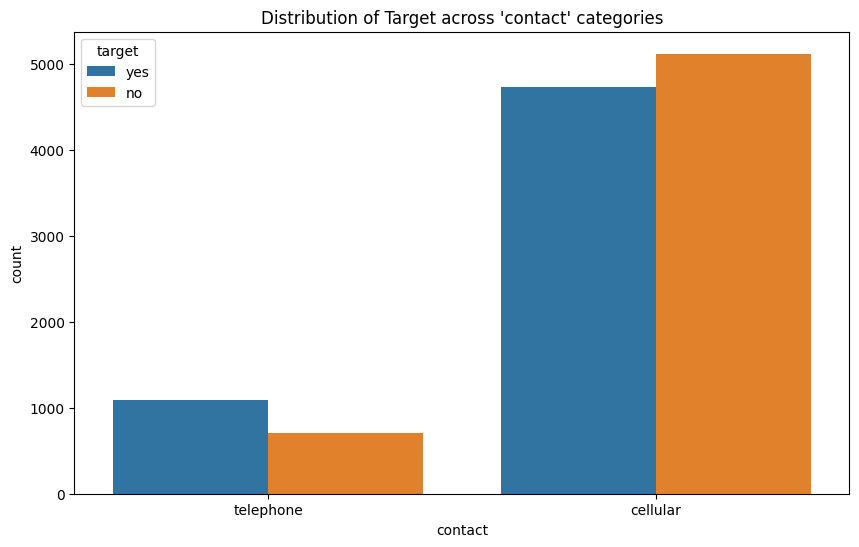

In [23]:
# Bar plot for 'poutcome'
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='poutcome', hue='target')
plt.title("Distribution of Target across 'poutcome' categories")
plt.show()

# Bar plot for 'contact'
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='contact', hue='target')
plt.title("Distribution of Target across 'contact' categories")
plt.show()

# Feature Engineering

**Encoding categorical variables**

In [24]:
# Converting 'Last_contact_date' into a categorical column 'is_weekend'

train_df['last contact date'] = pd.to_datetime(train_df['last contact date'])

# Directly create 'is_weekend' column based on 'last_contact_date'
train_df['is_weekend'] = train_df['last contact date'].dt.weekday.isin([5, 6]).astype(int)  # 5 for Saturday, 6 for Sunday

# Drop the original 'last_contact_date' column if no longer needed
train_df.drop('last contact date', axis=1, inplace=True)


# train_df


In [25]:
# Count the occurrences of each value in the 'target' column
target_counts = train_df['target'].value_counts()
print(target_counts)

#Class Imbalance: from the output it is clear that there is heavy class imbalance

# If the target variable is imbalanced we hae to downsample the majority class

target
yes    5827
no     5827
Name: count, dtype: int64


In [26]:
#Using label encoding on columns having binary categories like (yes/no)
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# List of columns to be label encoded
binary_columns = ['default', 'housing', 'loan', 'target', 'contact']

# Apply label encoding
for col in binary_columns:
    train_df[col] = label_encoder.fit_transform(train_df[col])


In [27]:
train_df

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target,is_weekend
0,89,self-employed,divorced,tertiary,1,96072,0,0,1,680,14,652,238,failure,1,0
1,56,management,married,tertiary,0,79,0,0,0,82,2,-1,0,success,0,0
2,41,housemaid,single,secondary,1,74359,0,0,1,2383,10,437,154,failure,1,1
3,30,management,single,tertiary,0,536,0,0,0,244,1,105,1,success,1,0
4,35,technician,married,secondary,0,2201,0,0,1,350,1,-1,0,failure,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11649,37,admin.,married,secondary,0,274,1,0,0,731,3,-1,0,failure,1,0
11650,46,technician,married,secondary,0,363,1,0,0,209,3,-1,0,other,0,0
11651,25,blue-collar,single,secondary,0,76,0,1,0,50,4,-1,0,other,0,0
11652,45,management,married,secondary,0,4105,1,0,0,49,2,-1,0,other,0,1


One-hot encoding: Used to convert categorical columns with no inherent order (nominal variables) into a series of binary columns.

In [28]:
# using one-hot encoding on columns having more than two categories

# List of categorical columns to be one-hot encoded
categorical_columns = ['job', 'marital', 'education','poutcome']

# One-Hot Encoding using pd.get_dummies
train_df = pd.get_dummies(train_df, columns=categorical_columns, drop_first=True)


In [29]:
train_df

,age,default,balance,housing,loan,contact,duration,campaign,pdays,previous,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,poutcome_other,poutcome_success
0,89,1,96072,0,0,1,680,14,652,238,...,False,False,False,False,False,False,False,True,False,False
1,56,0,79,0,0,0,82,2,-1,0,...,False,False,False,False,True,False,False,True,False,True
2,41,1,74359,0,0,1,2383,10,437,154,...,False,False,False,False,False,True,True,False,False,False
3,30,0,536,0,0,0,244,1,105,1,...,False,False,False,False,False,True,False,True,False,True
4,35,0,2201,0,0,1,350,1,-1,0,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11649,37,0,274,1,0,0,731,3,-1,0,...,False,False,False,False,True,False,True,False,False,False
11650,46,0,363,1,0,0,209,3,-1,0,...,False,False,True,False,True,False,True,False,True,False
11651,25,0,76,0,1,0,50,4,-1,0,...,False,False,False,False,False,True,True,False,True,False
11652,45,0,4105,1,0,0,49,2,-1,0,...,False,False,False,False,True,False,True,False,True,False


# Feature Scaling


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Assuming numerical columns are stored in a list called `numerical_columns`
numerical_columns = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Apply standardization to the numerical columns
train_df[numerical_columns] = scaler.fit_transform(train_df[numerical_columns])


In [31]:
pd.set_option('display.max_columns', None)
train_df

,age,default,balance,housing,loan,contact,duration,campaign,pdays,previous,target,is_weekend,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,poutcome_other,poutcome_success
0,2.933915,1,3.758323,0,0,1,-0.046233,0.478643,2.532307,3.386302,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
1,0.793913,0,-0.446179,0,0,0,-0.618921,-0.411634,-0.612385,-0.404157,0,0,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True
2,-0.178815,1,2.807292,0,0,1,1.584683,0.181884,1.496918,2.048493,1,1,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False
3,-0.892149,0,-0.426162,0,0,0,-0.463778,-0.485824,-0.101914,-0.388231,1,0,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,True
4,-0.567906,0,-0.353235,0,0,1,-0.362265,-0.485824,-0.612385,-0.404157,1,1,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11649,-0.438209,0,-0.437638,1,0,0,0.002608,-0.337444,-0.612385,-0.404157,1,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
11650,0.145428,0,-0.433740,1,0,0,-0.497297,-0.337444,-0.612385,-0.404157,0,0,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False
11651,-1.216391,0,-0.446311,0,1,0,-0.649566,-0.263255,-0.612385,-0.404157,0,0,True,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False
11652,0.080579,0,-0.269840,1,0,0,-0.650524,-0.411634,-0.612385,-0.404157,0,1,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False


# Doing the train - test split 

In [32]:
from sklearn.model_selection import train_test_split as tts

# Assuming 'train_df' is your complete training DataFrame
X = train_df.drop(columns = ['target'], axis=1)
y = train_df['target']
X_train = X
y_train = y
# Splitting data into 80% training and 20% validation sets
# X_train, X_val, y_train, y_val = tts(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape


(11654, 27)

# **Model 1** # **Logistic Regression**

* the first  model to be used by me.
* I used the model without handling the missing values of 'contact' and 'poutcome' column and got the score of .49829
* I got to know the significance of 'contact' and 'poutcome' column performing some EDA, so these columns could not be deleted.
* I handled the missing values of 'contact' using Predictive imputation technique an did the same for 'poutcome' and after this my score came down to what dummy model outputted .
* i got to know that the problem was in 'poutcome' column because it was not imputed correctly so i just filled the values in it using the 'mode' and again i got the score to .49829
* **After Hyperparamter tuning**
* After doing hyperparameter tuning and selecting the best hyperparameters using the GridSearchCV i got no improvement and the model's score was stagnant.

*  **What Inferences can we draw from this**

*  According to my knowledge my data has complex, nonlinear relationships so logistic regression struggles to capture them effectively.
*  The model is overfitting(performing poorly on unseen data)

*  **What I am not doing correctly and can possibly improve my score using same model**

*  I am currently not handling outliers.
*  Handling the class imbalance

In [33]:
from sklearn.linear_model import LogisticRegression

# Separate the features and target variable

# *********************This i used when i was using the full data for training**************************************

# X_train = train_df.drop('target', axis=1)  # All features except the target
# y_train = train_df['target']  # Target variable

# best_model = LogisticRegression(
#     C=0.01,
#     max_iter=100,
#     penalty=None,  # No regularization
#     solver='lbfgs'
# )

# # Train the model using the training data
# best_model.fit(X_train, y_train)
# *******************************************************************************************************
# I already have train and test so:

# lgr_model = LogisticRegression(
#     C=0.01,
#     max_iter=100,
#     penalty=None,  # No regularization
#     solver='lbfgs'
# )
# lgr_model.fit(X_train, y_train)

In [34]:
X_train.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'contact', 'duration',
       'campaign', 'pdays', 'previous', 'is_weekend', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'poutcome_other',
       'poutcome_success'],
      dtype='object')

**Doing Hyper parameter tuning**

In [35]:
# from sklearn.model_selection import GridSearchCV

# # Define the hyperparameter grid
# param_grid = {
#     'penalty': ['l1', 'l2', 'elasticnet', None],  # Regularization term
#     'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
#     'solver': ['lbfgs', 'liblinear', 'saga'],  # Optimization algorithm
#     'max_iter': [100, 200, 300]
# }

# # Create a GridSearchCV object
# grid_search = GridSearchCV(
#     estimator=LogisticRegression(),
#     param_grid=param_grid,
#     scoring='f1_macro',  # Using f1_macro as per the competition requirements
#     cv=5,  # Number of cross-validation folds
#     verbose=1,
#     n_jobs=-1  # Use all available cores
# )

# # Fit the grid search on the training data
# grid_search.fit(X_train, y_train)

# # Display the best parameters and the corresponding score
# print("Best Parameters:", grid_search.best_params_)
# print("Best F1 Score:", grid_search.best_score_)
# **********************************************************************************************************

# from sklearn.model_selection import GridSearchCV

# # Define the hyperparameter grid
# param_grid = {
#     'penalty': ['l2', None],  # Regularization term (l2 or None)
#     'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
#     'solver': ['lbfgs', 'liblinear', 'saga'],  # Optimization algorithm
#     'max_iter': [100, 200, 300]
# }

# # Create a GridSearchCV object
# grid_search = GridSearchCV(
#     estimator=LogisticRegression(),
#     param_grid=param_grid,
#     scoring='f1_macro',  # Using f1_macro as per the competition requirements
#     cv=5,  # Number of cross-validation folds
#     verbose=1,
#     n_jobs=-1  # Use all available cores
# )

# # Fit the grid search on the training data
# grid_search.fit(X_train, y_train)

# # Display the best parameters and the corresponding score
# print("Best Parameters:", grid_search.best_params_)
# print("Best F1 Score:", grid_search.best_score_)


**Hyperparameter tuning- RF model**

In [36]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'bootstrap': [True, False]
# }

# grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
# grid_search.fit(X_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# best_rf_model = grid_search.best_estimator_


# **Model 3 # Gradient Boosting Classifier**

In [37]:
# from sklearn.ensemble import GradientBoostingClassifier

# gb_model = GradientBoostingClassifier(random_state=42)
# gb_model.fit(X_train, y_train)

**Hyper parameter tuning GB Model**

In [38]:
# from sklearn.model_selection import GridSearchCV

# # Define the hyperparameter grid for GradientBoostingClassifier
# param_grid_gb = {
#     'n_estimators': [50, 100, 150, 200],  # Number of boosting stages (trees)
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinking to prevent overfitting
#     'max_depth': [3, 5, 7],  # Maximum depth of each individual tree
#     'subsample': [0.8, 0.9, 1.0],  # Fraction of samples used for fitting each tree
# }

# # Create a GridSearchCV object
# grid_search_gb = GridSearchCV(
#     estimator=GradientBoostingClassifier(random_state=42),
#     param_grid=param_grid_gb,
#     scoring='f1_macro',  # Using f1_macro as per the competition requirements
#     cv=5,  # Number of cross-validation folds
#     verbose=1,
#     n_jobs=-1  # Use all available cores for parallel processing
# )

# # Fit the grid search on the training data
# grid_search_gb.fit(X_train, y_train)

# # Display the best hyperparameters and the corresponding score
# print("Best Hyperparameters:", grid_search_gb.best_params_)
# print("Best F1 Score:", grid_search_gb.best_score_)

# # Get the best model
# best_gb_model = grid_search_gb.best_estimator_

In [39]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import precision_score, recall_score, f1_score
# import numpy as np

# # Define the parameter distribution for GradientBoostingClassifier
# param_dist_gb = {
#     'n_estimators': np.arange(50, 201, 50),  # Number of boosting stages (trees)
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinking to prevent overfitting
#     'max_depth': [3, 5, 7, 10],  # Maximum depth of each individual tree
#     'subsample': [0.8, 0.9, 1.0],  # Fraction of samples used for fitting each tree
# }

# # Create a RandomizedSearchCV object
# random_search_gb = RandomizedSearchCV(
#     estimator=GradientBoostingClassifier(random_state=42),
#     param_distributions=param_dist_gb,
#     n_iter=100,  # Number of random combinations to try
#     scoring='f1_macro',  # Using f1_macro as per the competition requirements
#     cv=5,  # Number of cross-validation folds
#     verbose=1,
#     random_state=42,  # For reproducibility
#     n_jobs=-1  # Use all available cores for parallel processing
# )

# # Fit the randomized search on the training data
# random_search_gb.fit(X_train, y_train)

# # Display the best hyperparameters and the corresponding score
# print("Best Hyperparameters:", random_search_gb.best_params_)
# print("Best F1 Score:", random_search_gb.best_score_)

# # Get the best model
# best_gb_model = random_search_gb.best_estimator_

# Checking model performance on the validation data

In [40]:
# from sklearn.ensemble import RandomForestClassifier
# import matplotlib.pyplot as plt

# # Fit a Random Forest model
# rf_model = RandomForestClassifier(bootstrap = True, max_depth = 10, max_features = 'log2', n_estimators = 100, random_state = 42)
# rf_model.fit(X_train, y_train)

# # Get feature importance
# importances = rf_model.feature_importances_

# # Create a DataFrame to store the feature names and their importance
# feature_importance = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': importances
# })

# # Sort the features by importance
# feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# # Plot the feature importance
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Importance'])
# plt.title('Feature Importance using Random Forest')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()

# # Display the feature importance
# print(feature_importance)


# Test DATA -- preparing for real shit

In [41]:
# Load the test data
test_df = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv")


**Preprocess the test data**

In [42]:
test_df['job'].fillna(test_df['job'].mode()[0], inplace=True)

# Fill missing values in 'education' column with the mode for test data
test_df['education'].fillna(test_df['education'].mode()[0], inplace=True)







# Extract rows where 'contact' is not missing for training the model
test_df_known = test_df[test_df['contact'].notna()]
test_df_missing = test_df[test_df['contact'].isna()]

# Encoding 'contact' column in test_df_known since it's the target variable
label_encoder = LabelEncoder()
test_df_known['contact_encoded'] = label_encoder.fit_transform(test_df_known['contact'])

# Selecting features (age, job, marital, education, default, balance, housing, loan)
# features = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']

features = ['age','marital', 'education', 'default', 'balance', 'housing', 'loan']
X = pd.get_dummies(test_df_known[features], drop_first=True)  # One-hot encoding for categorical variables
y = test_df_known['contact_encoded']

# Splitting data for training and validation
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X, y, test_size=0.2, random_state=42)

# Building a simple classifier model
rf_model_c = RandomForestClassifier(random_state=42)
rf_model_c.fit(X_train_c, y_train_c)

# Checking model accuracy (optional, for evaluation purposes)
accuracy = rf_model_c.score(X_val_c, y_val_c)
print(f"Model Accuracy on Validation Data: {accuracy:.2f}")

# Preparing the missing data for prediction
X_missing = pd.get_dummies(test_df_missing[features], drop_first=True)

# Align the columns of X_missing with X_train (this ensures no issues due to missing columns)
X_missing = X_missing.reindex(columns=X_train_c.columns, fill_value=0)

# Predicting missing values
predicted_contact_encoded = rf_model_c.predict(X_missing)

# Converting the predicted labels back to original 'contact' categories
predicted_contact = label_encoder.inverse_transform(predicted_contact_encoded)

# Imputing the missing values in the original DataFrame
test_df.loc[test_df['contact'].isna(), 'contact'] = predicted_contact

/tmp/ipykernel_17/2152928510.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['job'].fillna(test_df['job'].mode()[0], inplace=True)
/tmp/ipykernel_17/2152928510.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Model Accuracy on Validation Data: 0.85


In [43]:
# test_df['poutcome'].fillna(test_df['poutcome'].mode()[0], inplace=True)

# Assuming you have a DataFrame 'test_df' where 'poutcome' column has missing values
# Extract rows where 'poutcome' is not missing for training the model
test_df_known_poutcome = test_df[test_df['poutcome'].notna()]
test_df_missing_poutcome = test_df[test_df['poutcome'].isna()]

# Encoding 'poutcome' column in test_df_known_poutcome since it's the target variable
label_encoder_poutcome = LabelEncoder()
test_df_known_poutcome['poutcome_encoded'] = label_encoder_poutcome.fit_transform(test_df_known_poutcome['poutcome'])

# Selecting features for prediction (you can customize this list as needed)
features_poutcome = ['age','marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'pdays','previous']  # Adding 'contact' as a feature since it may influence 'poutcome'
X_poutcome = pd.get_dummies(test_df_known_poutcome[features_poutcome], drop_first=True)  # One-hot encoding for categorical variables
y_poutcome = test_df_known_poutcome['poutcome_encoded']

# Splitting data for training and validation
X_train_poutcome, X_val_poutcome, y_train_poutcome, y_val_poutcome = train_test_split(X_poutcome, y_poutcome, test_size=0.2, random_state=42)

# Building a simple classifier model for predicting 'poutcome'
rf_model_poutcome = RandomForestClassifier(random_state = 42)
rf_model_poutcome.fit(X_train_poutcome, y_train_poutcome)
# Checking model accuracy (optional, for evaluation purposes)
accuracy_poutcome = rf_model_poutcome.score(X_val_poutcome, y_val_poutcome)

print(f"Model Accuracy on Validation Data for 'poutcome': {accuracy_poutcome:.2f}")

# Preparing the missing data for prediction
X_missing_poutcome = pd.get_dummies(test_df_missing_poutcome[features_poutcome], drop_first=True)

# Align the columns of X_missing_poutcome with X_train_poutcome (ensuring consistent feature alignment)
X_missing_poutcome = X_missing_poutcome.reindex(columns=X_train_poutcome.columns, fill_value=0)

# Predicting missing values for 'poutcome'
predicted_poutcome_encoded = rf_model_poutcome.predict(X_missing_poutcome)

# Converting the predicted labels back to original 'poutcome' categories
predicted_poutcome = label_encoder_poutcome.inverse_transform(predicted_poutcome_encoded)

# Imputing the missing values in the original DataFrame
test_df.loc[test_df['poutcome'].isna(), 'poutcome'] = predicted_poutcome

# Displaying the result
print("Missing values in 'poutcome' have been imputed using prediction.")


/tmp/ipykernel_17/4072714604.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_known_poutcome['poutcome_encoded'] = label_encoder_poutcome.fit_transform(test_df_known_poutcome['poutcome'])


Model Accuracy on Validation Data for 'poutcome': 0.49
Missing values in 'poutcome' have been imputed using prediction.


In [44]:
# # importances = rf_model_poutcome.feature_importances_
# importances = lgr_model_poutcome.feature_importances_

# # Create a DataFrame to store the feature names and their importance
# feature_importance = pd.DataFrame({
#     'Feature': X_train_poutcome.columns,
#     'Importance': importances
# })

# # Sort the features by importance
# feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# # Plot the feature importance
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Importance'])
# plt.title('Feature Importance using Random Forest')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()

# # Display the feature importance
# print(feature_importance)

In [45]:
# Converting 'Last_contact_date' into a categorical column 'is_weekend' for test data
test_df['last contact date'] = pd.to_datetime(test_df['last contact date'])

# Directly create 'is_weekend' column based on 'last_contact_date' for test data
test_df['is_weekend'] = test_df['last contact date'].dt.weekday.isin([5, 6]).astype(int)  # 5 for Saturday, 6 for Sunday

# Drop the original 'last_contact_date' column if no longer needed
test_df.drop('last contact date', axis=1, inplace=True)

In [46]:
# Using label encoding on columns having binary categories like (yes/no) for test data
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# List of columns to be label encoded (excluding 'target' since it's not in test.csv)
binary_columns = ['default', 'housing', 'loan', 'contact']
# Apply label encoding to test data
for col in binary_columns:
    test_df[col] = label_encoder.fit_transform(test_df[col])

# Using one-hot encoding on columns having more than two categories for test data
# List of categorical columns to be one-hot encoded
# categorical_columns = ['job', 'marital', 'education','poutcome']
categorical_columns = ['job','marital', 'education','poutcome']
# One-Hot Encoding using pd.get_dummies for test data
test_df = pd.get_dummies(test_df, columns=categorical_columns, drop_first=True)

# Ensure that both train and test dataframes have the same columns after one-hot encoding
# Assuming train_df is already aligned as per the previous steps
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

# Using StandardScaler for numerical columns in test data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# List of numerical columns
numerical_columns = ['age', 'balance', 'duration', 'campaign', 'pdays','previous']

# Apply standardization to the numerical columns for test data
test_df[numerical_columns] = scaler.fit_transform(test_df[numerical_columns])
test_df[numerical_columns] = scaler.transform(test_df[numerical_columns])  # Use transform on test data, not fit_transform

# **Model 2 #Random Forest Classifier**


In [47]:
from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(bootstrap = True, max_depth = 10, max_features = 'log2', n_estimators = 100, random_state = 42)
# # Fit the model on the training data
# rf_model.fit(X_train, y_train)
# X_train.columns

In [48]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'bootstrap': [True, False]
# }

# grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
# grid_search.fit(X_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# Best parameters found:  {'bootstrap': False, 'max_depth': 30, 'max_features': 'auto', 'n_estimators': 100}
# best_rf_model = RandomForestClassifier(bootstrap = False, max_depth = 30, max_features= 'auto', n_estimators = 100, random_state = 42)
# best_rf_model.fit(X_train, y_train)

# K - fold Cross validation

In [49]:
# from sklearn.model_selection import KFold


# # Number of splits for K-Fold Cross-Validation
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Loop through each fold
# for train_index, val_index in kf.split(X_train):
#     # Split data into training and validation sets for this fold
#     X_kf_train, X_kf_val = X_train.iloc[train_index], X_train.iloc[val_index]
#     y_kf_train, y_kf_val = y_train.iloc[train_index], y_train.iloc[val_index]

#     # Initialize and train the model
#     # model = LogisticRegression(C=0.01, max_iter=100, penalty='none', solver='lbfgs', random_state=42)
#     model = RandomForestClassifier(bootstrap = True, max_depth = 10, max_features = 'log2', n_estimators = 100, random_state = 42)
#     model.fit(X_kf_train, y_kf_train)

In [50]:
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# # Placeholder lists to store scores across all folds
# accuracy_scores = []
# f1_scores = []
# precision_scores = []
# recall_scores = []

#     # Predict on validation set for this fold
# y_kf_pred = model.predict(X_kf_val)

# # Calculate metrics for this fold
# accuracy_scores.append(accuracy_score(y_kf_val, y_kf_pred))
# f1_scores.append(f1_score(y_kf_val, y_kf_pred, pos_label= 1))  # Assuming binary classification with '1' as the positive label
# precision_scores.append(precision_score(y_kf_val, y_kf_pred, pos_label=1))
# recall_scores.append(recall_score(y_kf_val, y_kf_pred, pos_label=1))

# # Calculate average scores across all folds
# print(f"Average Accuracy: {sum(accuracy_scores) / len(accuracy_scores):.4f}")
# print(f"Average F1 Score: {sum(f1_scores) / len(f1_scores):.4f}")
# print(f"Average Precision: {sum(precision_scores) / len(precision_scores):.4f}")
# print(f"Average Recall: {sum(recall_scores) / len(recall_scores):.4f}")

# XGB Model

In [51]:
from sklearn.model_selection import KFold, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Number of splits for K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Store scores for each fold
fold_accuracies = []
fold_f1_scores = []

# Loop through each fold
for train_index, val_index in kf.split(X_train):
    # Split data into training and validation sets for this fold
    X_kf_train, X_kf_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_kf_train, y_kf_val = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the XGBoost model
    xgb_model.fit(X_kf_train, y_kf_train)

    # Predict on the validation set
    y_kf_pred = xgb_model.predict(X_kf_val)

    # Evaluate and store metrics
    accuracy = accuracy_score(y_kf_val, y_kf_pred)
    f1 = f1_score(y_kf_val, y_kf_pred, pos_label=1)  # Assuming 'yes' is the positive class
    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

# Print average performance across folds
print(f"Average Accuracy: {sum(fold_accuracies) / len(fold_accuracies):.4f}")
print(f"Average F1 Score: {sum(fold_f1_scores) / len(fold_f1_scores):.4f}")


Average Accuracy: 0.7975
Average F1 Score: 0.8029


In [52]:
# # Define hyperparameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],         # Number of trees
#     'max_depth': [3, 5, 7],                # Maximum depth of each tree
#     'learning_rate': [0.01, 0.1, 0.2],     # Step size shrinkage
#     'subsample': [0.8, 1.0],               # Fraction of samples used for fitting each tree
#     'colsample_bytree': [0.8, 1.0],        # Fraction of features used for fitting each tree
#     'gamma': [0, 1],                       # Minimum loss reduction required to split a node
# }

# # Initialize the XGBoost classifier
# xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# # Perform Grid Search with Cross-Validation
# grid_search = GridSearchCV(estimator=xgb_model, 
#                            param_grid=param_grid, 
#                            cv=5, 
#                            scoring='f1',  # Scoring based on F1-score
#                            verbose=1,
#                            n_jobs=-1)

# # Fit the GridSearchCV
# grid_search.fit(X_train, y_train)

# # Best parameters and score
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best F1 Score: {grid_search.best_score_:.4f}")

# # Use the best model
# best_xgb_model = grid_search.best_estimator_

# # Evaluate on the validation/test set
# y_pred_test = best_xgb_model.predict(X_test)
# test_f1_score = f1_score(y_test, y_pred_test, pos_label=1)
# print(f"F1 Score on Test Data: {test_f1_score:.4f}")

# Normal Validation

In [53]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# # Predicting on the validation set
# y_val_pred = best_rf_model.predict(X_val)

# # Calculating metrics
# accuracy = accuracy_score(y_val, y_val_pred)
# precision = precision_score(y_val, y_val_pred) 
# recall = recall_score(y_val, y_val_pred)
# f1 = f1_score(y_val, y_val_pred)

# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")

# # Optional: Detailed classification report
# print("\nClassification Report:\n")
# print(classification_report(y_val, y_val_pred))


# Prediciting label for Test.csv

In [54]:
# Prepare the features from the test data
X_test = test_df.drop(columns = ['target'], axis=1)  # If 'target' is there, drop it

X_test.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'contact', 'duration',
       'campaign', 'pdays', 'previous', 'is_weekend', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'poutcome_other',
       'poutcome_success'],
      dtype='object')

In [55]:
# Predict using the trained model
# y_pred = gb_model.predict(X_test)
# y_pred = best_rf_model.predict(X_test) # using best hyperparameter for random forest algo
y_pred = xgb_model.predict(X_test) #using the best model i got using the hyperparameter tuning ## LGR model

# Submission

In [56]:
# Assuming y_pred contains the predicted values (0 or 1)
y_pred_labels = ['yes' if pred == 1 else 'no' for pred in y_pred]

# Create the submission DataFrame
submission = pd.DataFrame({
    'id': range(0,X_test.shape[0]),  # Assuming the test data contains an 'id' column
    'target': y_pred_labels  # 'yes' or 'no' predictions
})

# Save the submission file
submission.to_csv('submission.csv', index=False)
